# Retrieving texts and counting words

In this example, we'll retrieve the texts of speeches from a remote server and do a basic word count.

## Scenario

Let's say we want to know how many words Achilles speaks to each of his interlocutors. We can search the DICES database for the relevant speeches using the API. Then, to count the number of words, we'll first have to retrieve the text of the speeches themselves. Since the DICES **Speech** objects include CTS URNS, we can request the passages from a remote server. 

## Preliminaries

### The DICES API

First step is to instantiate a connection to the DICES api. 

In [1]:
from dicesapi import DicesAPI
api = DicesAPI()

### Connection to the digital library

Text-retrieval from CTS endpoints and associated processing tools are meant to be optional. Code for these features lives in the module `text`, but the way to import its functionality is with the DicesAPI method `initializeCts()`. This must be called once on the API object before you can download passages.

You can optionally pass a URL pattern telling the API where to get the texts. By default, passages are retrieved from Perseus's [Scaife ATLAS server](https://atlas.perseus.tufts.edu/).

In [2]:
api.initializeCts()

### Matplotlib for figures

Let's also import **pyplot**, for drawing a simple bar graph of the results. Note the Jupyter magic `%matplotlib inline` to display the figure right in the notebook. Some people like `%matplotlib notebook` better — it gives you some fancier display options.

In [3]:
from matplotlib import pyplot as plt
%matplotlib inline

## Download the speeches

### First, the speech metadata from DICES

Using the API, we can search speeches using a set of key-value pairs. For now, JSON results from the API are paged, so if your search has a lot of results, you may have to wait for several pages to download.

In [4]:
speeches = api.getSpeeches(spkr_name='Achilles', work_title='Iliad')

### Next, the text of the speeches from Perseus

To download the text of a passage from the remote CTS server, use the `.fetchPassage()` method. This will download the passage as TEI XML as a new Speech attribute called `.passage`.

In [5]:
# iterate over all speeches
for s in speeches:
    
    # retrieve the passage from the remote library
    s.fetchPassage()
    
    if s.passage is None:
        print(f'Failed to download {s.urn}')

## Looking at speech text

The downloaded speech text and its associated methods and attributes are bundled as a Passage object. In the code above, we attached this directly to the speech as e.g., `speech.passage`.

### TEI XML

The original format of the data from Perseus is TEI XML. If you want, you can access this as `passage.xml`.

In [6]:
print(speeches[0].passage.xml)

<Element {http://www.tei-c.org/ns/1.0}TEI at 0x10ebc8940>


To work with XML content, use a package like **lxml**.

In [7]:
from lxml import etree
print(etree.tostring(speeches[0].passage.xml, encoding="Unicode", pretty_print=True))

<TEI xmlns="http://www.tei-c.org/ns/1.0" xmlns:py="http://codespeak.net/lxml/objectify/pytype" py:pytype="TREE">
  <text xml:lang="grc">
    <body>
      <div type="edition" n="urn:cts:greekLit:tlg0012.tlg001.perseus-grc2" xml:lang="grc">
        <div type="textpart" subtype="Book" n="1">
          <q>
            <l n="59">Ἀτρεΐδη νῦν ἄμμε παλιμπλαγχθέντας ὀΐω</l>
            <l n="60">ἂψ ἀπονοστήσειν, εἴ κεν θάνατόν γε φύγοιμεν,</l>
            <l n="61">εἰ δὴ ὁμοῦ πόλεμός τε δαμᾷ καὶ λοιμὸς Ἀχαιούς·</l>
            <l n="62">ἀλλʼ ἄγε δή τινα μάντιν ἐρείομεν ἢ ἱερῆα</l>
            <l n="63">ἢ καὶ ὀνειροπόλον, καὶ γάρ τʼ ὄναρ ἐκ Διός ἐστιν,</l>
            <l n="64">ὅς κʼ εἴποι ὅ τι τόσσον ἐχώσατο Φοῖβος Ἀπόλλων,</l>
            <l n="65">εἴτʼ ἄρʼ ὅ γʼ εὐχωλῆς ἐπιμέμφεται ἠδʼ ἑκατόμβης,</l>
            <l n="66">αἴ κέν πως ἀρνῶν κνίσης αἰγῶν τε τελείων</l>
            <l n="67">βούλεται ἀντιάσας ἡμῖν ἀπὸ λοιγὸν ἀμῦναι.</l>
          </q>
        </div>
      </div>
    </body>
  </te

### DICES Line Array

The DICES client automatically converts CTS TEI XML into a simple list of verse lines, storing line number, text, and a serial number for sorting. This is saved as `passage.line_array`

In [8]:
speeches[0].passage.line_array

[{'n': '59', 'seq': 0, 'text': 'Ἀτρεΐδη νῦν ἄμμε παλιμπλαγχθέντας ὀΐω'},
 {'n': '60', 'seq': 1, 'text': 'ἂψ ἀπονοστήσειν, εἴ κεν θάνατόν γε φύγοιμεν,'},
 {'n': '61',
  'seq': 2,
  'text': 'εἰ δὴ ὁμοῦ πόλεμός τε δαμᾷ καὶ λοιμὸς Ἀχαιούς·'},
 {'n': '62', 'seq': 3, 'text': 'ἀλλʼ ἄγε δή τινα μάντιν ἐρείομεν ἢ ἱερῆα'},
 {'n': '63',
  'seq': 4,
  'text': 'ἢ καὶ ὀνειροπόλον, καὶ γάρ τʼ ὄναρ ἐκ Διός ἐστιν,'},
 {'n': '64',
  'seq': 5,
  'text': 'ὅς κʼ εἴποι ὅ τι τόσσον ἐχώσατο Φοῖβος Ἀπόλλων,'},
 {'n': '65',
  'seq': 6,
  'text': 'εἴτʼ ἄρʼ ὅ γʼ εὐχωλῆς ἐπιμέμφεται ἠδʼ ἑκατόμβης,'},
 {'n': '66', 'seq': 7, 'text': 'αἴ κέν πως ἀρνῶν κνίσης αἰγῶν τε τελείων'},
 {'n': '67', 'seq': 8, 'text': 'βούλεται ἀντιάσας ἡμῖν ἀπὸ λοιγὸν ἀμῦναι.'}]

Here's how you might iterate over the lines in your code:

In [9]:
for line in speeches[0].passage.line_array:
    print(line["n"], line["text"])

59 Ἀτρεΐδη νῦν ἄμμε παλιμπλαγχθέντας ὀΐω
60 ἂψ ἀπονοστήσειν, εἴ κεν θάνατόν γε φύγοιμεν,
61 εἰ δὴ ὁμοῦ πόλεμός τε δαμᾷ καὶ λοιμὸς Ἀχαιούς·
62 ἀλλʼ ἄγε δή τινα μάντιν ἐρείομεν ἢ ἱερῆα
63 ἢ καὶ ὀνειροπόλον, καὶ γάρ τʼ ὄναρ ἐκ Διός ἐστιν,
64 ὅς κʼ εἴποι ὅ τι τόσσον ἐχώσατο Φοῖβος Ἀπόλλων,
65 εἴτʼ ἄρʼ ὅ γʼ εὐχωλῆς ἐπιμέμφεται ἠδʼ ἑκατόμβης,
66 αἴ κέν πως ἀρνῶν κνίσης αἰγῶν τε τελείων
67 βούλεται ἀντιάσας ἡμῖν ἀπὸ λοιγὸν ἀμῦναι.


### Single string output

The full text of the speech as a single string, without line numbers, is accessible as `passage.text`.

In [10]:
print(speeches[0].passage.text)

Ἀτρεΐδη νῦν ἄμμε παλιμπλαγχθέντας ὀΐω ἂψ ἀπονοστήσειν, εἴ κεν θάνατόν γε φύγοιμεν, εἰ δὴ ὁμοῦ πόλεμός τε δαμᾷ καὶ λοιμὸς Ἀχαιούς· ἀλλʼ ἄγε δή τινα μάντιν ἐρείομεν ἢ ἱερῆα ἢ καὶ ὀνειροπόλον, καὶ γάρ τʼ ὄναρ ἐκ Διός ἐστιν, ὅς κʼ εἴποι ὅ τι τόσσον ἐχώσατο Φοῖβος Ἀπόλλων, εἴτʼ ἄρʼ ὅ γʼ εὐχωλῆς ἐπιμέμφεται ἠδʼ ἑκατόμβης, αἴ κέν πως ἀρνῶν κνίσης αἰγῶν τε τελείων βούλεται ἀντιάσας ἡμῖν ἀπὸ λοιγὸν ἀμῦναι.


### HTML output

For a more readable version, a convenience method, `passage.toHTML()`, formats the line array as HTML.

In [11]:
from IPython.display import HTML
display(HTML(speeches[0].passage.toHTML()))

59,Ἀτρεΐδη νῦν ἄμμε παλιμπλαγχθέντας ὀΐω
60,"ἂψ ἀπονοστήσειν, εἴ κεν θάνατόν γε φύγοιμεν,"
61,εἰ δὴ ὁμοῦ πόλεμός τε δαμᾷ καὶ λοιμὸς Ἀχαιούς·
62,ἀλλʼ ἄγε δή τινα μάντιν ἐρείομεν ἢ ἱερῆα
63,"ἢ καὶ ὀνειροπόλον, καὶ γάρ τʼ ὄναρ ἐκ Διός ἐστιν,"
64,"ὅς κʼ εἴποι ὅ τι τόσσον ἐχώσατο Φοῖβος Ἀπόλλων,"
65,"εἴτʼ ἄρʼ ὅ γʼ εὐχωλῆς ἐπιμέμφεται ἠδʼ ἑκατόμβης,"
66,αἴ κέν πως ἀρνῶν κνίσης αἰγῶν τε τελείων
67,βούλεται ἀντιάσας ἡμῖν ἀπὸ λοιγὸν ἀμῦναι.


## Simple word count

Now we're ready to count Achilles' words. For this demo, we're going to use the Python string method `split()`, which just cuts breaks a string on whitespace. It doesn't distinguish words from punctuation marks, as you'll see in the output below. For more sophisticated tokenization, we might use natural language processing tools trained on Latin and Ancient Greek. 

In [12]:
# split first speech into words
words = speeches[0].passage.text.split()

# count them
print(len(words), "words in this speech.\n")

# inspect the first 10 words
for i, w in enumerate(words[:10]):
    print (i, w)

70 words in this speech.

0 Ἀτρεΐδη
1 νῦν
2 ἄμμε
3 παλιμπλαγχθέντας
4 ὀΐω
5 ἂψ
6 ἀπονοστήσειν,
7 εἴ
8 κεν
9 θάνατόν


### Count per addressee

We'll tally how many words he speaks to each of his interlocutors using a dictionary: keys will be addressee names, and values will be word counts.

In [13]:
# initialize a new dictionary
count = dict()

# iterate over all the speeches
for s in speeches:

    # iterate over all addressees (sometimes he speaks to several people at once)
    for addressee in s.addr:

        # update the count for this addressee
        count[addressee.name] = count.get(addressee.name, 0) + len(s.passage.text.split())

### Examine the results

🤔 Let's see whether it worked!

In [14]:
for name in sorted(count):
    print(name, count[name])

Achilles 319
Aeneas 161
Agamemnon 1206
Aias (son of Oileus) 47
Aias (son of Telamon) 115
Antilochus 47
Apollo 48
Asteropaeus 125
Athena 51
Balios 61
Calchas 49
Eurybates 84
Greeks 426
Hector 264
Idomeneus 47
Iris 71
Lycaon 200
Myrmidons 110
Nestor 45
Odysseus 939
Patroclus 648
Phoinix 122
Priam 596
Scamander 30
Spercheius 62
Talthybius 84
Thetis 772
Xanthos 61
Zeus 239
dead Hector 16
dead Iphition 26
dead Lycaon 97
dead Patroclus 406
ghost of Patroclus 33
leaders of the Greeks (Greek soldiers) 199


**Note**: Achilles himself appears in the list because DICES counts the speaker as an addressee for soliloquies and explicit addresses to oneself or, e.g., one's own heart. This also applies to speeches marked *secum* or *inter se*.

### Make a simple graph with pyplot

Let's visualize the counts with a simple bar chart.

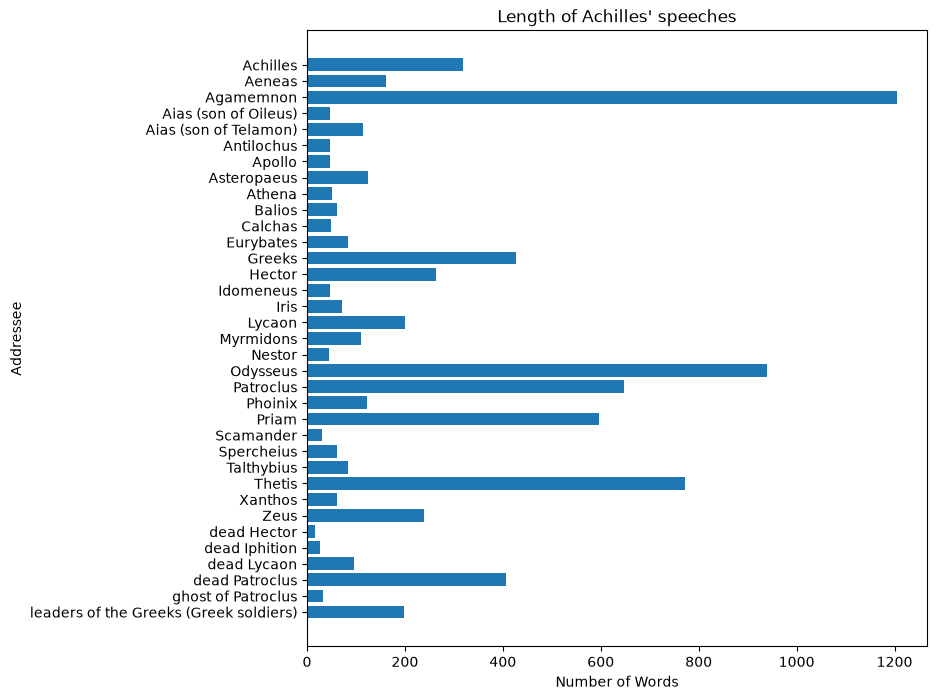

In [15]:
# data for the graph
names = sorted(count)
y_pos = range(len(names))
bars = [count[name] for name in names]

# create a new figure
fig, ax = plt.subplots(figsize=(8, 8))

# draw the bars
ax.barh(y_pos, bars, align='center')

# annotate the graph
ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('Number of Words')
ax.set_ylabel('Addressee')
ax.set_title('Length of Achilles\' speeches')

plt.show()